<a href="https://colab.research.google.com/github/evinracher/3010192-advanced-simulation/blob/main/assignments/assignments2-montecarlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

In this notebook, we will solve a Monte Carlo problem consisting of:

**Problem description**

A supermarket sells boxes of milk daily. Historical demand data from **364 days (52 weeks)** is available. This data is used to estimate the **probability distribution of daily demand**.

Using **Monte Carlo simulation**, the system must simulate **100 weeks of operation** to evaluate different inventory policies.

An inventory policy is defined by:

* number of boxes ordered **on Monday**
* number of boxes ordered **on Wednesday**

Simulation rules:

* The simulation starts **Monday morning with zero inventory**.
* Orders arrive **at the beginning of the day** they are placed.
* One demand realization occurs **each day**.
* If demand exceeds inventory, the excess demand is **lost (no backorders)**.

Costs:

* **Inventory holding cost:** 800 per box per day
* **Order cost:**

  * fixed: 15,000 per order
  * variable: 100 per box ordered

Objective:

Find the **ordering policy (Monday order, Wednesday order)** that:

1. Achieves a **service level ≥ 80%** (percentage of days without stockouts).
2. **Minimizes total cost** (inventory cost + ordering cost).


In [9]:
# Install required packages
!pip install pandas

# Initial configuration

In [2]:
# Imports
import random
import pandas as pd

# Reproducibility
random.seed(42)

# Historical demand data
demand_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
frequencies = [1, 5, 12, 19, 27, 59, 74, 59, 49, 37, 22]

# Problem parameters
historical_days = 364
days_per_week = 7
simulation_weeks = 100
simulation_days = simulation_weeks * days_per_week

initial_inventory = 0
inventory_cost_per_box_per_day = 800
fixed_order_cost = 15000
variable_order_cost_per_box = 100
target_service_level = 0.80

weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

In [3]:
# Build probability table from historical demand data

# Calculate total frequency (should match historical_days)
total_frequency = sum(frequencies)

# Calculate relative frequencies (probabilities)
relative_frequencies = [f / total_frequency for f in frequencies]

# Calculate cumulative probabilities
cumulative_probabilities = []
cumsum = 0
for rel_freq in relative_frequencies:
    cumsum += rel_freq
    cumulative_probabilities.append(cumsum)

# Create probability table as DataFrame
probability_table = pd.DataFrame({
    'demand': demand_values,
    'absolute_frequency': frequencies,
    'relative_frequency': relative_frequencies,
    'cumulative_probability': cumulative_probabilities
})

# Display the probability table
probability_table

,demand,absolute_frequency,relative_frequency,cumulative_probability
0,0,1,0.002747,0.002747
1,1,5,0.013736,0.016484
2,2,12,0.032967,0.049451
3,3,19,0.052198,0.101648
4,4,27,0.074176,0.175824
5,5,59,0.162088,0.337912
6,6,74,0.203297,0.541209
7,7,59,0.162088,0.703297
8,8,49,0.134615,0.837912
9,9,37,0.101648,0.939560


In [11]:
def generate_random_demand(probability_table):
    """
    Generate a random daily demand value using the inverse transform method.
    
    Parameters:
    - probability_table: DataFrame with columns 'demand' and 'cumulative_probability'
    
    Returns:
    - A randomly generated demand value based on the probability distribution
    """
    # Generate a random number between 0 and 1
    r = random.random()
    
    # Find the first cumulative probability >= r
    for index, row in probability_table.iterrows():
        if r <= row['cumulative_probability']:
            return row['demand']
    
    # Fallback (should not reach here if probabilities are correct)
    return probability_table.iloc[-1]['demand']

# Test: generate 10 random demand values
print("Testing random demand generation:")
test_demands = [generate_random_demand(probability_table) for _ in range(10)]
print(test_demands)

Testing random demand generation:
[np.float64(7.0), np.float64(9.0), np.float64(8.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(8.0), np.float64(7.0), np.float64(5.0), np.float64(4.0)]


In [12]:
def simulate_day(current_inventory, demand, order_quantity):
    """
    Simulate one day of inventory operations.
    
    Parameters:
    - current_inventory: inventory at the start of the day (before order arrives)
    - demand: daily demand
    - order_quantity: number of boxes ordered (arrives at start of day)
    
    Returns:
    - Dictionary containing all simulation results for the day
    """
    # Step 1: Add order at the beginning of the day
    inventory_after_order = current_inventory + order_quantity
    
    # Step 2: Satisfy demand with available inventory
    if demand > inventory_after_order:
        # Stockout occurs
        stockout = True
        unmet_demand = demand - inventory_after_order
        end_inventory = 0
    else:
        # Demand is fully satisfied
        stockout = False
        unmet_demand = 0
        end_inventory = inventory_after_order - demand
    
    # Step 3: Calculate daily inventory holding cost
    holding_cost = end_inventory * inventory_cost_per_box_per_day
    
    # Step 4: Calculate order cost (only if order was placed)
    if order_quantity > 0:
        order_cost = fixed_order_cost + (order_quantity * variable_order_cost_per_box)
    else:
        order_cost = 0
    
    # Step 5: Return all results as dictionary
    return {
        'inventory_start': current_inventory,
        'order_quantity': order_quantity,
        'inventory_after_order': inventory_after_order,
        'demand': demand,
        'stockout': stockout,
        'unmet_demand': unmet_demand,
        'end_inventory': end_inventory,
        'holding_cost': holding_cost,
        'order_cost': order_cost
    }

# Example: simulate one day with initial inventory=5, demand=3, order=10 boxes
example = simulate_day(current_inventory=5, demand=3, order_quantity=10)
print("Example day simulation:")
for key, value in example.items():
    print(f"  {key}: {value}")

Example day simulation:
  inventory_start: 5
  order_quantity: 10
  inventory_after_order: 15
  demand: 3
  stockout: False
  unmet_demand: 0
  end_inventory: 12
  holding_cost: 9600
  order_cost: 16000


In [13]:
def simulate_policy(monday_order, wednesday_order, probability_table, simulation_weeks=100):
    """
    Simulate an inventory policy over multiple weeks.
    
    Parameters:
    - monday_order: number of boxes to order every Monday
    - wednesday_order: number of boxes to order every Wednesday
    - probability_table: DataFrame with demand probability distribution
    - simulation_weeks: number of weeks to simulate (default: 100)
    
    Returns:
    - Dictionary containing simulation summary metrics
    """
    # Initialize simulation variables
    total_days = simulation_weeks * days_per_week
    current_inventory = initial_inventory  # Start with zero inventory
    
    # Initialize accumulators
    total_holding_cost = 0
    total_order_cost = 0
    stockout_days = 0
    total_lost_units = 0
    
    # Simulate each day
    for day_number in range(total_days):
        # Determine day of the week (0=Monday, 1=Tuesday, ..., 6=Sunday)
        day_of_week = day_number % days_per_week
        day_name = weekdays[day_of_week]
        
        # Determine order quantity for this day
        if day_name == "Monday":
            order_quantity = monday_order
        elif day_name == "Wednesday":
            order_quantity = wednesday_order
        else:
            order_quantity = 0
        
        # Generate random demand for this day
        demand = generate_random_demand(probability_table)
        
        # Simulate the day
        day_result = simulate_day(current_inventory, demand, order_quantity)
        
        # Update inventory for next day
        current_inventory = day_result['end_inventory']
        
        # Accumulate costs
        total_holding_cost += day_result['holding_cost']
        total_order_cost += day_result['order_cost']
        
        # Track stockouts
        if day_result['stockout']:
            stockout_days += 1
        
        # Track lost units
        total_lost_units += day_result['unmet_demand']
    
    # Calculate summary metrics
    total_cost = total_holding_cost + total_order_cost
    service_level = (total_days - stockout_days) / total_days
    
    # Return summary
    return {
        'monday_order': monday_order,
        'wednesday_order': wednesday_order,
        'total_days': total_days,
        'total_holding_cost': total_holding_cost,
        'total_order_cost': total_order_cost,
        'total_cost': total_cost,
        'stockout_days': stockout_days,
        'service_level': service_level,
        'total_lost_units': total_lost_units
    }

# Example: test the policy with monday_order=20, wednesday_order=15
test_policy = simulate_policy(monday_order=20, wednesday_order=15, probability_table=probability_table)
print("Test policy simulation (Monday=20, Wednesday=15):")
for key, value in test_policy.items():
    print(f"  {key}: {value}")

Test policy simulation (Monday=20, Wednesday=15):
  monday_order: 20
  wednesday_order: 15
  total_days: 700
  total_holding_cost: 4028800.0
  total_order_cost: 3350000
  total_cost: 7378800.0
  stockout_days: 188
  service_level: 0.7314285714285714
  total_lost_units: 933.0


In [14]:
# Evaluate multiple candidate inventory policies

# Define ranges for order quantities to test
monday_order_range = range(0, 51)  # 0 to 50 boxes
wednesday_order_range = range(0, 51)  # 0 to 50 boxes

# Initialize list to store results
results = []

# Reset random seed for reproducibility across all policy evaluations
random.seed(42)

# Counter for progress tracking
total_policies = len(monday_order_range) * len(wednesday_order_range)
count = 0

print(f"Evaluating {total_policies} candidate policies...")

# Evaluate each combination of Monday and Wednesday orders
for monday_qty in monday_order_range:
    for wednesday_qty in wednesday_order_range:
        # Reset seed before each simulation for fair comparison
        random.seed(42)
        
        # Simulate this policy
        result = simulate_policy(monday_qty, wednesday_qty, probability_table)
        
        # Store results
        results.append({
            'monday_order': result['monday_order'],
            'wednesday_order': result['wednesday_order'],
            'service_level': result['service_level'],
            'total_lost_units': result['total_lost_units'],
            'inventory_cost': result['total_holding_cost'],
            'order_cost': result['total_order_cost'],
            'total_cost': result['total_cost']
        })
        
        count += 1
        if count % 500 == 0:
            print(f"  Progress: {count}/{total_policies} policies evaluated")

# Create DataFrame with all results
policies_df = pd.DataFrame(results)

print(f"\nEvaluation complete! Total policies evaluated: {len(policies_df)}")
print(f"\nFirst few policies:")
policies_df.head(10)

Evaluating 2601 candidate policies...
  Progress: 500/2601 policies evaluated
  Progress: 1000/2601 policies evaluated
  Progress: 1500/2601 policies evaluated
  Progress: 2000/2601 policies evaluated
  Progress: 2500/2601 policies evaluated

Evaluation complete! Total policies evaluated: 2601

First few policies:


,monday_order,wednesday_order,service_level,total_lost_units,inventory_cost,order_cost,total_cost
0,0,0,0.005714,4410.0,0.0,0,0.0
1,0,1,0.007143,4310.0,800.0,1510000,1510800.0
2,0,2,0.011429,4210.0,2400.0,1520000,1522400.0
3,0,3,0.014286,4110.0,6400.0,1530000,1536400.0
4,0,4,0.022857,4010.0,12000.0,1540000,1552000.0
5,0,5,0.055714,3910.0,22400.0,1550000,1572400.0
6,0,6,0.090000,3810.0,51200.0,1560000,1611200.0
7,0,7,0.118571,3710.0,99200.0,1570000,1669200.0
8,0,8,0.137143,3610.0,163200.0,1580000,1743200.0
9,0,9,0.160000,3510.0,237600.0,1590000,1827600.0


In [27]:
# Filter for feasible policies that meet the service level constraint

# Filter policies with service level >= target (0.80)
feasible_policies = policies_df[policies_df['service_level'] >= target_service_level].copy()

print(f"Total policies evaluated: {len(policies_df)}")
print(f"Feasible policies (service level >= {target_service_level}): {len(feasible_policies)}")
print(f"Infeasible policies: {len(policies_df) - len(feasible_policies)}")

# Sort feasible policies by total cost (ascending)
feasible_policies_sorted = feasible_policies.sort_values('total_cost', ascending=True)

# Display the best feasible policy (minimum cost)
print("\n" + "="*60)
print("BEST FEASIBLE POLICY (Minimum Cost with Service Level >= 80%)")
print("="*60)
best_policy = feasible_policies_sorted.iloc[0]
print(f"Monday order quantity: {best_policy['monday_order']:.0f} boxes")
print(f"Wednesday order quantity: {best_policy['wednesday_order']:.0f} boxes")
print(f"Service level: {best_policy['service_level']:.4f} ({best_policy['service_level']*100:.2f}%)")
print(f"Total lost units: {best_policy['total_lost_units']:.0f}")
print(f"Inventory holding cost: ${best_policy['inventory_cost']:,.2f}")
print(f"Order cost: ${best_policy['order_cost']:,.2f}")
print(f"TOTAL COST: ${best_policy['total_cost']:,.2f}")
print("="*60)

# Display top 10 feasible policies
print(f"\nTop 10 Feasible Policies (sorted by total cost):")
feasible_policies_sorted.head(10)

Total policies evaluated: 2601
Feasible policies (service level >= 0.8): 1850
Infeasible policies: 751

BEST FEASIBLE POLICY (Minimum Cost with Service Level >= 80%)
Monday order quantity: 15 boxes
Wednesday order quantity: 23 boxes
Service level: 0.8043 (80.43%)
Total lost units: 610
Inventory holding cost: $4,612,000.00
Order cost: $3,380,000.00
TOTAL COST: $7,992,000.00

Top 10 Feasible Policies (sorted by total cost):


,monday_order,wednesday_order,service_level,total_lost_units,inventory_cost,order_cost,total_cost
788,15,23,0.804286,610.0,4612000.0,3380000,7992000.0
838,16,22,0.805714,610.0,4706400.0,3380000,8086400.0
888,17,21,0.814286,610.0,4828800.0,3380000,8208800.0
938,18,20,0.817143,610.0,4978400.0,3380000,8358400.0
689,13,26,0.815714,510.0,4971200.0,3390000,8361200.0
739,14,25,0.817143,510.0,5005600.0,3390000,8395600.0
639,12,27,0.805714,510.0,5007200.0,3390000,8397200.0
789,15,24,0.825714,510.0,5056800.0,3390000,8446800.0
589,11,28,0.805714,510.0,5120000.0,3390000,8510000.0
988,19,19,0.818571,610.0,5135200.0,3380000,8515200.0


## Graphs

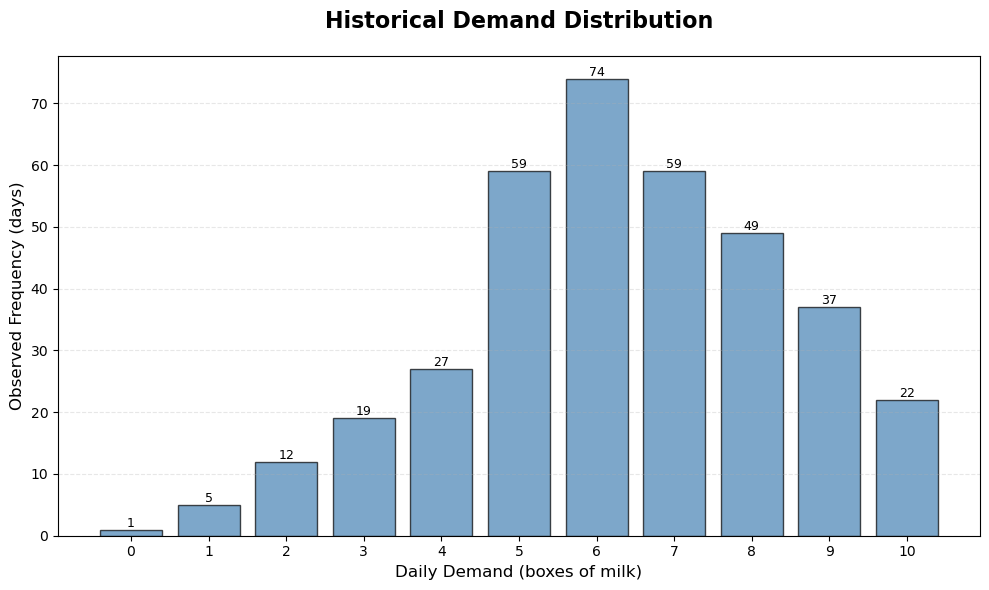

In [16]:
# Plot the historical demand distribution

import matplotlib.pyplot as plt

# Create figure with appropriate size
plt.figure(figsize=(10, 6))

# Create bar chart
# X-axis: demand values (number of boxes)
# Y-axis: observed frequency (number of days)
plt.bar(demand_values, frequencies, color='steelblue', edgecolor='black', alpha=0.7)

# Add title and axis labels
plt.title('Historical Demand Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Daily Demand (boxes of milk)', fontsize=12)
plt.ylabel('Observed Frequency (days)', fontsize=12)

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Ensure x-axis shows all demand values
plt.xticks(demand_values)

# Add value labels on top of each bar
for i, (demand, freq) in enumerate(zip(demand_values, frequencies)):
    plt.text(demand, freq, str(freq), ha='center', va='bottom', fontsize=9)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

Probability Distribution of Daily Milk Demand:
    demand  frequency  probability_percent
0        0          1             0.274725
1        1          5             1.373626
2        2         12             3.296703
3        3         19             5.219780
4        4         27             7.417582
5        5         59            16.208791
6        6         74            20.329670
7        7         59            16.208791
8        8         49            13.461538
9        9         37            10.164835
10      10         22             6.043956

Total observations: 364
Sum of probabilities: 100.0000%


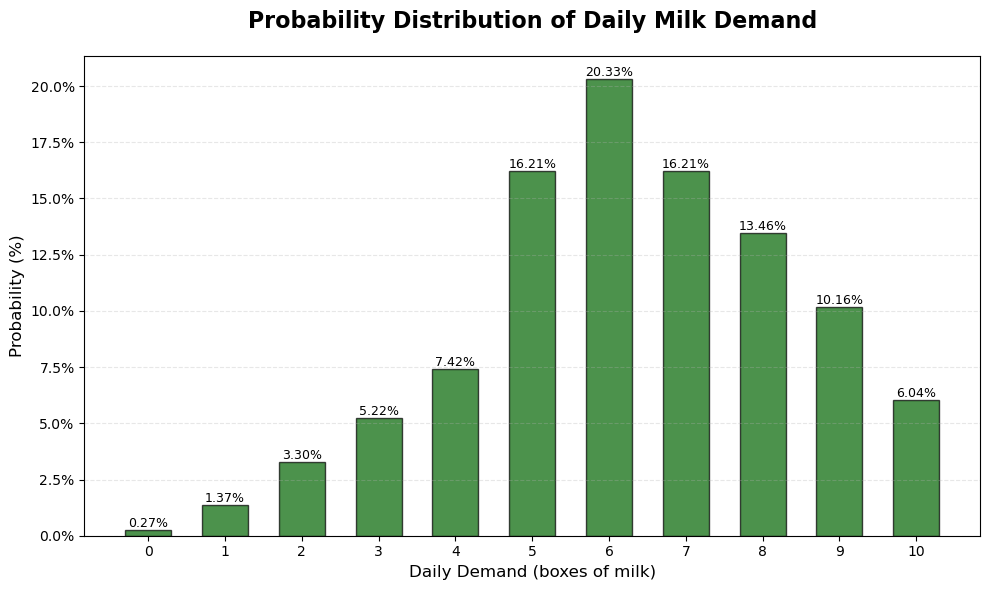

In [18]:
# Compute and visualize the probability distribution of daily demand

# Step 1: Calculate total number of observations
total_observations = sum(frequencies)

# Step 2: Calculate probability (relative frequency) for each demand value
probabilities = [freq / total_observations for freq in frequencies]

# Step 3: Convert probabilities to percentages
probabilities_percent = [prob * 100 for prob in probabilities]

# Step 4: Create DataFrame with demand, frequency, and probability (in percentage)
demand_distribution = pd.DataFrame({
    'demand': demand_values,
    'frequency': frequencies,
    'probability_percent': probabilities_percent
})

# Step 5: Display the probability distribution table
print("Probability Distribution of Daily Milk Demand:")
print(demand_distribution)
print(f"\nTotal observations: {total_observations}")
print(f"Sum of probabilities: {sum(probabilities_percent):.4f}%")

# Step 6: Plot the probability distribution
plt.figure(figsize=(10, 6))

# Create bar chart
# X-axis: demand (number of boxes per day)
# Y-axis: probability in percentage
plt.bar(demand_values, probabilities_percent, color='darkgreen', edgecolor='black', alpha=0.7, width=0.6)

# Add title and axis labels
plt.title('Probability Distribution of Daily Milk Demand', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Daily Demand (boxes of milk)', fontsize=12)
plt.ylabel('Probability (%)', fontsize=12)

# Add grid lines for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Ensure x-axis shows all demand values
plt.xticks(demand_values)

# Format y-axis to show percentages with 1 decimal place
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))

# Add value labels on top of each bar
for demand, prob_pct in zip(demand_values, probabilities_percent):
    plt.text(demand, prob_pct, f'{prob_pct:.2f}%', ha='center', va='bottom', fontsize=9)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

Demand Distribution with Cumulative Probabilities:
    demand  frequency  probability_percent  cumulative_probability
0        0          1             0.274725                0.002747
1        1          5             1.373626                0.016484
2        2         12             3.296703                0.049451
3        3         19             5.219780                0.101648
4        4         27             7.417582                0.175824
5        5         59            16.208791                0.337912
6        6         74            20.329670                0.541209
7        7         59            16.208791                0.703297
8        8         49            13.461538                0.837912
9        9         37            10.164835                0.939560
10      10         22             6.043956                1.000000

Final cumulative probability: 1.000000 (should be 1.0)


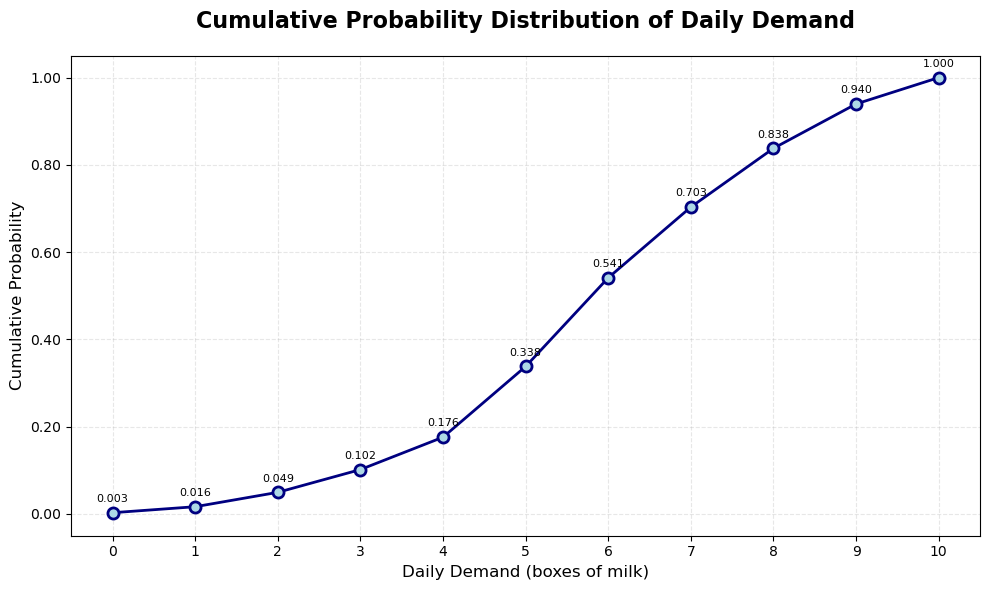

In [19]:
# Compute and visualize cumulative probability distribution

# Step 1: Convert percentages back to probabilities (0 to 1 scale) for cumulative calculation
probabilities_decimal = [p / 100 for p in probabilities_percent]

# Step 2: Calculate cumulative probabilities
cumulative_probs = []
cumsum = 0
for prob in probabilities_decimal:
    cumsum += prob
    cumulative_probs.append(cumsum)

# Step 3: Add cumulative probability column to the DataFrame
demand_distribution['cumulative_probability'] = cumulative_probs

# Step 4: Display the updated distribution table
print("Demand Distribution with Cumulative Probabilities:")
print(demand_distribution)
print(f"\nFinal cumulative probability: {cumulative_probs[-1]:.6f} (should be 1.0)")

# Step 5: Plot the cumulative probability distribution
plt.figure(figsize=(10, 6))

# Create line chart with markers
# X-axis: demand (number of boxes per day)
# Y-axis: cumulative probability
plt.plot(demand_values, cumulative_probs, color='navy', linewidth=2, 
         marker='o', markersize=8, markerfacecolor='lightblue', 
         markeredgecolor='navy', markeredgewidth=2)

# Add title and axis labels
plt.title('Cumulative Probability Distribution of Daily Demand', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Daily Demand (boxes of milk)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)

# Add grid lines for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Ensure x-axis shows all demand values
plt.xticks(demand_values)

# Format y-axis to show probabilities from 0 to 1
plt.ylim(-0.05, 1.05)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

# Add value labels on each point
for demand, cum_prob in zip(demand_values, cumulative_probs):
    plt.text(demand, cum_prob + 0.02, f'{cum_prob:.3f}', 
             ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

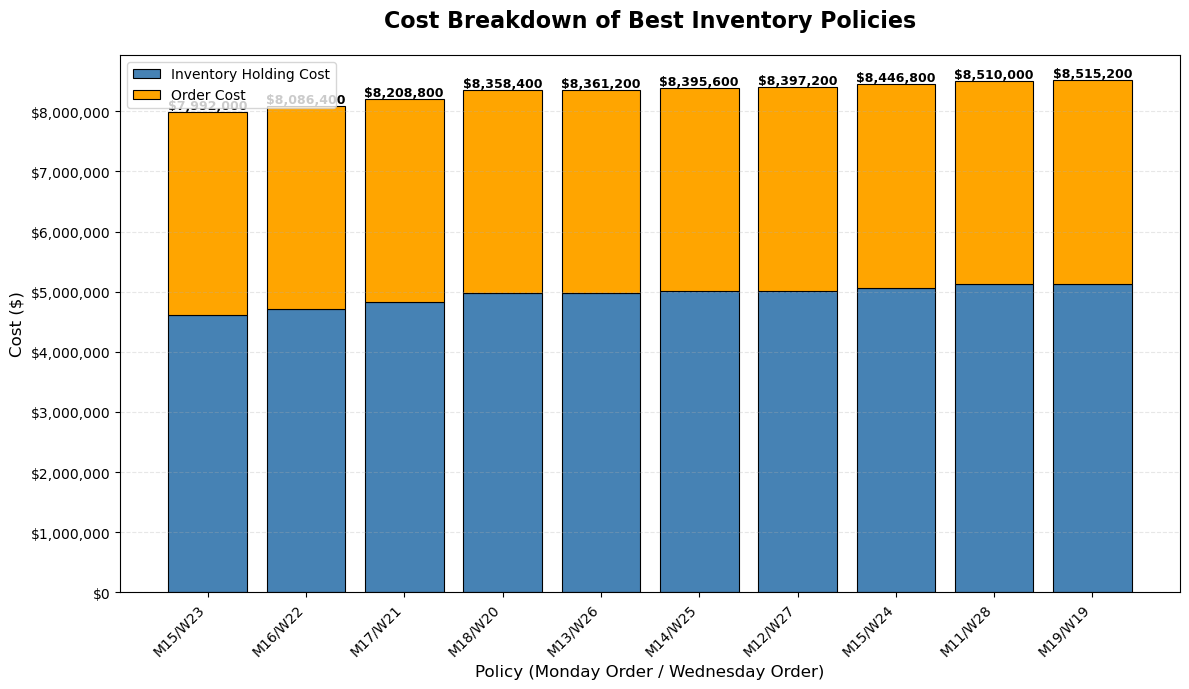


Top 10 Policies by Total Cost:
 monday_order  wednesday_order  service_level  inventory_cost  order_cost  total_cost
           15               23       0.804286       4612000.0     3380000   7992000.0
           16               22       0.805714       4706400.0     3380000   8086400.0
           17               21       0.814286       4828800.0     3380000   8208800.0
           18               20       0.817143       4978400.0     3380000   8358400.0
           13               26       0.815714       4971200.0     3390000   8361200.0
           14               25       0.817143       5005600.0     3390000   8395600.0
           12               27       0.805714       5007200.0     3390000   8397200.0
           15               24       0.825714       5056800.0     3390000   8446800.0
           11               28       0.805714       5120000.0     3390000   8510000.0
           19               19       0.818571       5135200.0     3380000   8515200.0


In [24]:
# Visualize cost breakdown for the best inventory policies

# Step 1: Select top 10 FEASIBLE policies with lowest total cost
# (must meet service level >= 80% constraint)
top_10_policies = feasible_policies_sorted.head(10).copy()

# Step 2: Create policy labels showing Monday and Wednesday order quantities
policy_labels = [f"M{int(row['monday_order'])}/W{int(row['wednesday_order'])}" 
                 for _, row in top_10_policies.iterrows()]

# Step 3: Extract cost components
inventory_costs = top_10_policies['inventory_cost'].values
order_costs = top_10_policies['order_cost'].values

# Step 4: Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))

# X-axis positions
x_positions = range(len(policy_labels))

# Create stacked bars
# Bottom layer: inventory cost
bar1 = ax.bar(x_positions, inventory_costs, label='Inventory Holding Cost', 
              color='steelblue', edgecolor='black', linewidth=0.8)

# Top layer: order cost (stacked on top of inventory cost)
bar2 = ax.bar(x_positions, order_costs, bottom=inventory_costs, 
              label='Order Cost', color='orange', edgecolor='black', linewidth=0.8)

# Step 5: Add title and axis labels
ax.set_title('Cost Breakdown of Best Inventory Policies', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Policy (Monday Order / Wednesday Order)', fontsize=12)
ax.set_ylabel('Cost ($)', fontsize=12)

# Step 6: Set x-axis labels
ax.set_xticks(x_positions)
ax.set_xticklabels(policy_labels, rotation=45, ha='right')

# Step 7: Add grid lines for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Step 8: Format y-axis to show costs with thousand separators
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:,.0f}'))

# Step 9: Add legend (positioned to avoid hiding bars)
ax.legend(loc='upper left', fontsize=10)

# Step 10: Add total cost labels on top of each bar
for i, (inv_cost, ord_cost) in enumerate(zip(inventory_costs, order_costs)):
    total = inv_cost + ord_cost
    ax.text(i, total, f'${total:,.0f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

# Step 11: Adjust layout to prevent label cutoff
plt.tight_layout()

# Step 12: Display the plot
plt.show()

# Step 13: Display the detailed table of top 10 policies
print("\nTop 10 Policies by Total Cost:")
print(top_10_policies[['monday_order', 'wednesday_order', 'service_level', 
                        'inventory_cost', 'order_cost', 'total_cost']].to_string(index=False))